<a href="https://colab.research.google.com/github/YashGujar55/bml/blob/main/BML5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df=pd.read_csv('/content/Medical_Cost.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
column_names=df.columns
print(column_names)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()

df['sex']=label_encoder.fit_transform(df['sex'])
df['smoker']=label_encoder.fit_transform(df['smoker'])
df['region']=label_encoder.fit_transform(df['region'])

scaled_features=(df.drop('smoker',axis=1))

Mean Absolute Error (MAE): 3154.705668541045
Mean Squared Error (MSE): 49003243.60682007
Root Mean Squared Error (RMSE): 7000.231682367382
R-squared (R2): 0.6843565603663775


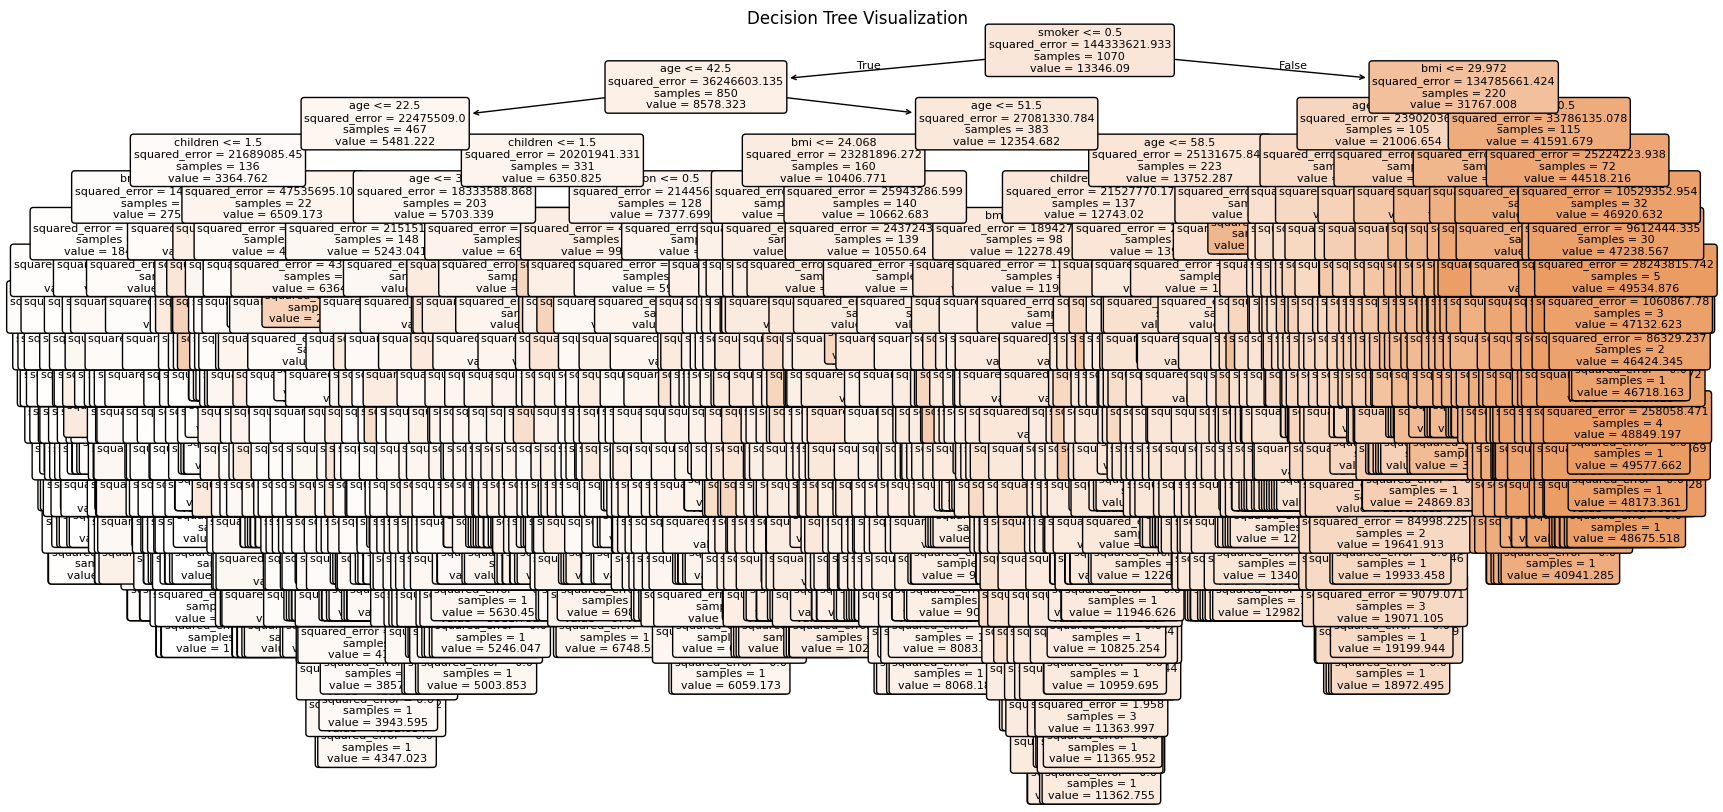

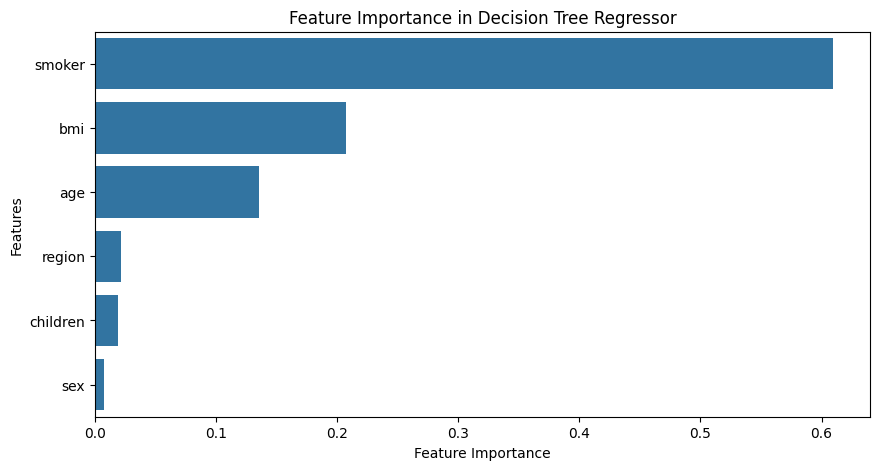

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('/content/Medical_Cost.csv')

# Encode categorical variables
label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])
df['region'] = label_encoder.fit_transform(df['region'])

# Define features and target variable
X = df.drop(columns=['charges'])  # Features
y = df['charges']  # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

# Plot Decision Tree
plt.figure(figsize=(20,10))  # Set figure size
plot_tree(model, feature_names=X.columns, filled=True, fontsize=8, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# Feature Importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Decision Tree Regressor")
plt.show()


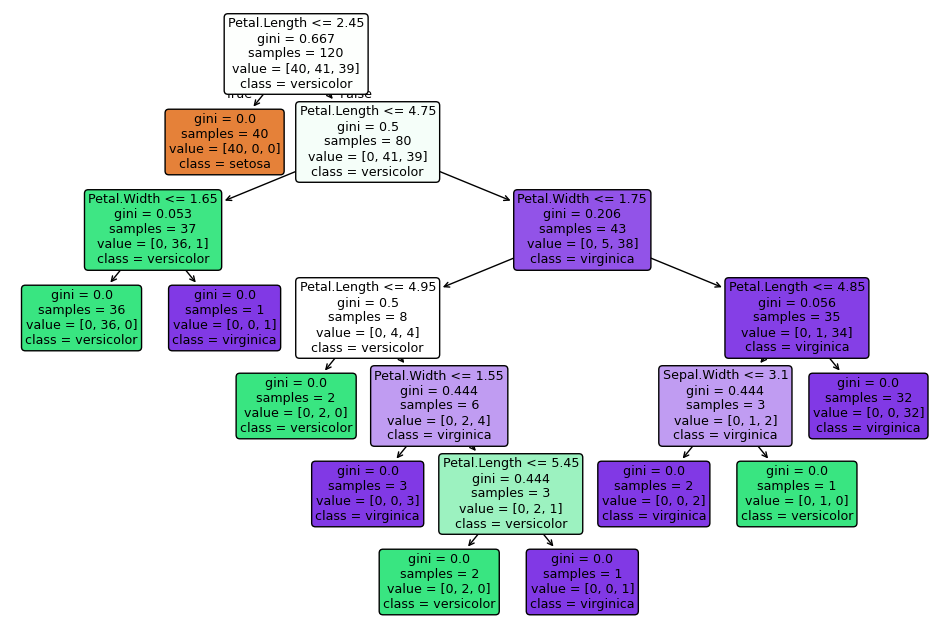

'decision_tree.pdf'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import graphviz
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz

# Load dataset
df = pd.read_csv("/content/IRIS.csv")  # Replace with your file path

# Drop unnecessary columns (ID)
df = df.drop(columns=['ID'])

# Define features and target
X = df.drop(columns=['Species'])
y = df['Species']

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Plot Decision Tree using Matplotlib
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True)
plt.show()

# Generate Decision Tree using Graphviz
dot_data = export_graphviz(clf, out_file=None, feature_names=X.columns, class_names=clf.classes_,
                           filled=True, rounded=True, special_characters=True)

# Render and display the tree
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Saves the tree as a file
graph.view()  # Opens the tree visualization
